# Analise de Produtos Agricolas com Machine Learning

## 1. Introducao
Este notebook apresenta uma analise de dados agricolas com foco na recomendacao de culturas a partir de condicoes de solo e clima.

**Objetivo:** explorar a base, identificar padroes e treinar modelos de classificacao para prever a melhor cultura (variavel `label`) com base em N, P, K, temperatura, umidade, pH e chuva.

O problema e de **classificacao multiclasse**: cada linha representa um conjunto de condicoes e a cultura recomendada para esse contexto.

In [6]:
%pip install scikit-learn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set(style="whitegrid")

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.1 MB 47.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 39.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----------------------- ---------------- 22.3/37.3 MB 105.0 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 100.6 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 77.0 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -----------

## 2. Carregamento dos dados
Nesta etapa, o arquivo CSV e carregado. Caso o nome padrao nao exista, o notebook tenta uma alternativa ou busca um arquivo CSV disponivel com a palavra `produtos_agricolas` no nome.

In [7]:
candidatos = [
    "produtos_agricolas.csv",
    "Atividade_Cap10_produtos_agricolas.csv"
]

arquivo = None
for nome in candidatos:
    if os.path.exists(nome):
        arquivo = nome
        break

if arquivo is None:
    csvs = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    similares = [f for f in csvs if "produtos_agricolas" in f.lower()]
    if similares:
        arquivo = similares[0]
    elif csvs:
        arquivo = csvs[0]

if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo CSV encontrado no diretorio.")

df = pd.read_csv(arquivo)
print("Arquivo carregado:", arquivo)

df.head()

Arquivo carregado: Atividade_Cap10_produtos_agricolas.csv


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [9]:
df.shape

(2200, 8)

In [10]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

A base possui um numero de linhas e colunas exibido acima. A variavel alvo e `label`, enquanto as variaveis numericas preditoras sao: `N`, `P`, `K`, `temperature`, `humidity`, `pH` e `rainfall`.

Essas variaveis representam nutrientes do solo e condicoes climaticas medias associadas a cada cultura.

## 3. Qualidade dos dados
A seguir, avaliamos valores ausentes, duplicados, distribuicao das culturas e estatisticas descritivas.

In [11]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

A analise acima permite verificar a presenca de valores ausentes e duplicados, alem da distribuicao das culturas.

Em geral, valores ausentes podem comprometer o treinamento; ja duplicados podem inflar artificiosamente a distribuicao. A tabela `describe` ajuda a identificar variaveis com maior variacao e escala.

## 4. Analise exploratoria com graficos
Os graficos a seguir investigam a distribuicao das culturas e a relacao entre nutrientes, clima e chuva.

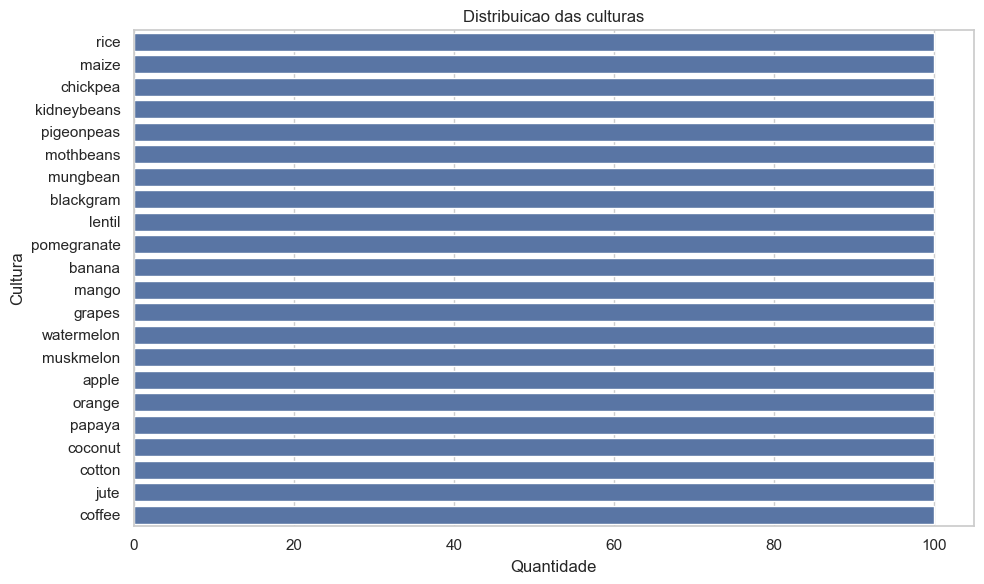

In [15]:
# Grafico 1 - Distribuicao das culturas
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="label", order=df["label"].value_counts().index)
plt.title("Distribuicao das culturas")
plt.xlabel("Quantidade")
plt.ylabel("Cultura")
plt.tight_layout()
plt.show()

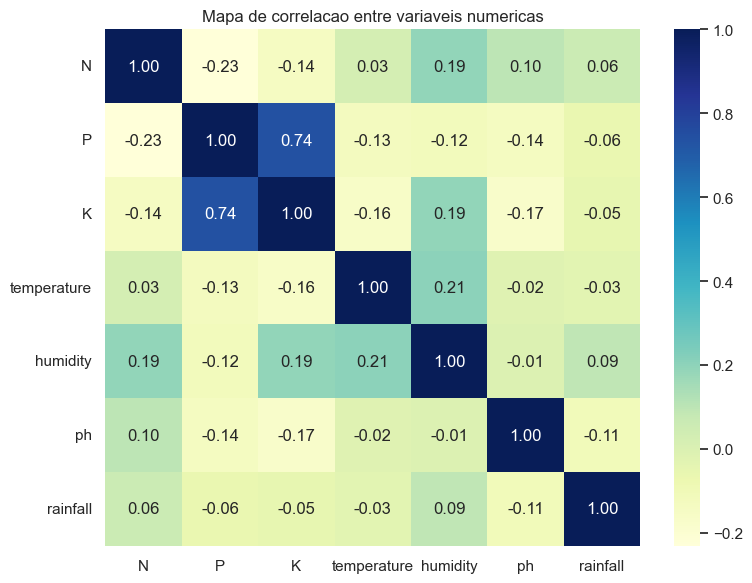

In [22]:
# Grafico 2 - Mapa de correlacao
plt.figure(figsize=(8, 6))
corr = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Mapa de correlacao entre variaveis numericas")
plt.tight_layout()
plt.show()

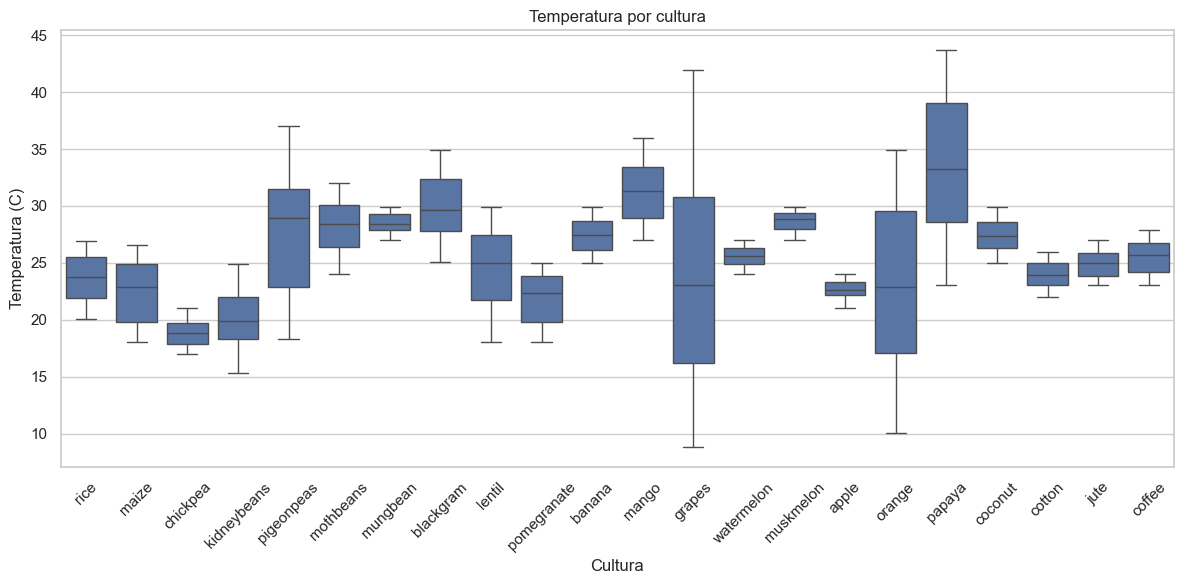

In [23]:
# Grafico 3 - Boxplot da temperatura por cultura
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="label", y="temperature")
plt.title("Temperatura por cultura")
plt.xlabel("Cultura")
plt.ylabel("Temperatura (C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

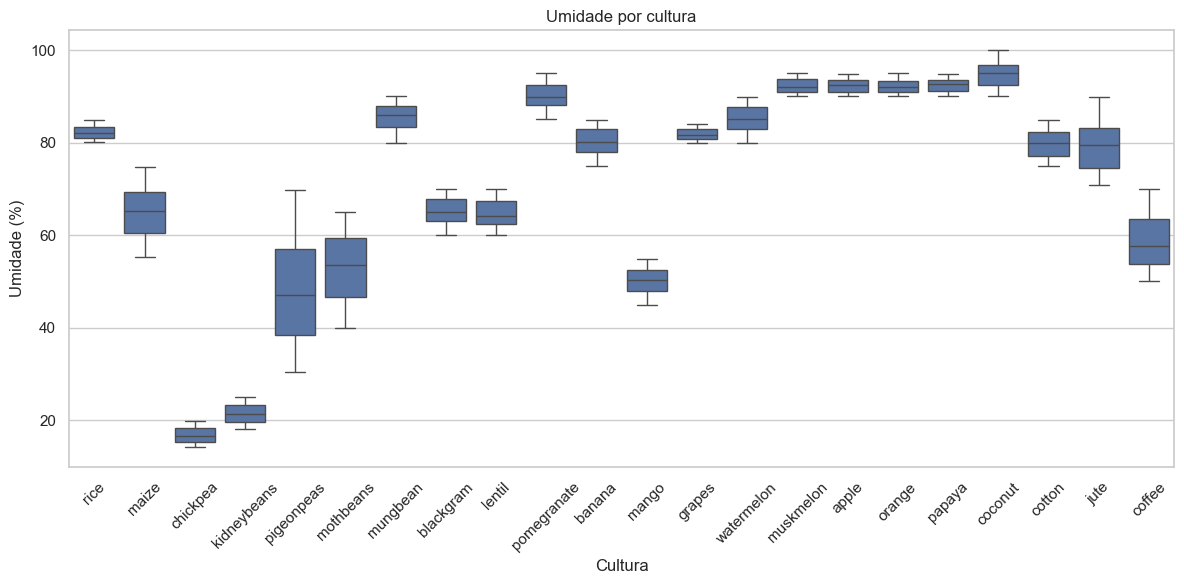

In [24]:
# Grafico 4 - Boxplot da umidade por cultura
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="label", y="humidity")
plt.title("Umidade por cultura")
plt.xlabel("Cultura")
plt.ylabel("Umidade (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

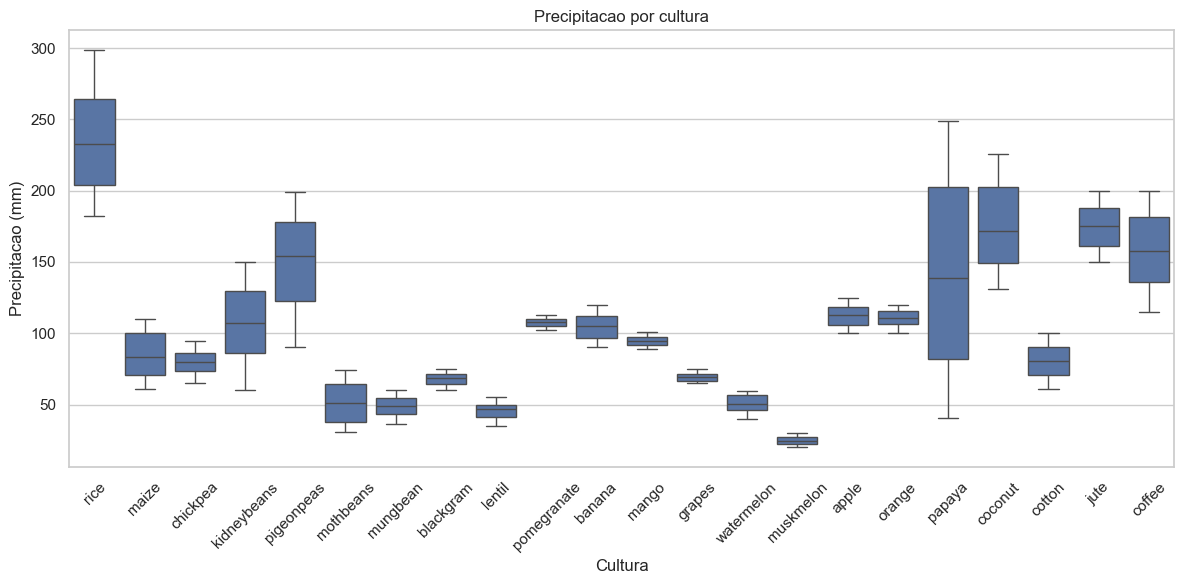

In [25]:
# Grafico 5 - Boxplot da precipitacao por cultura
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="label", y="rainfall")
plt.title("Precipitacao por cultura")
plt.xlabel("Cultura")
plt.ylabel("Precipitacao (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

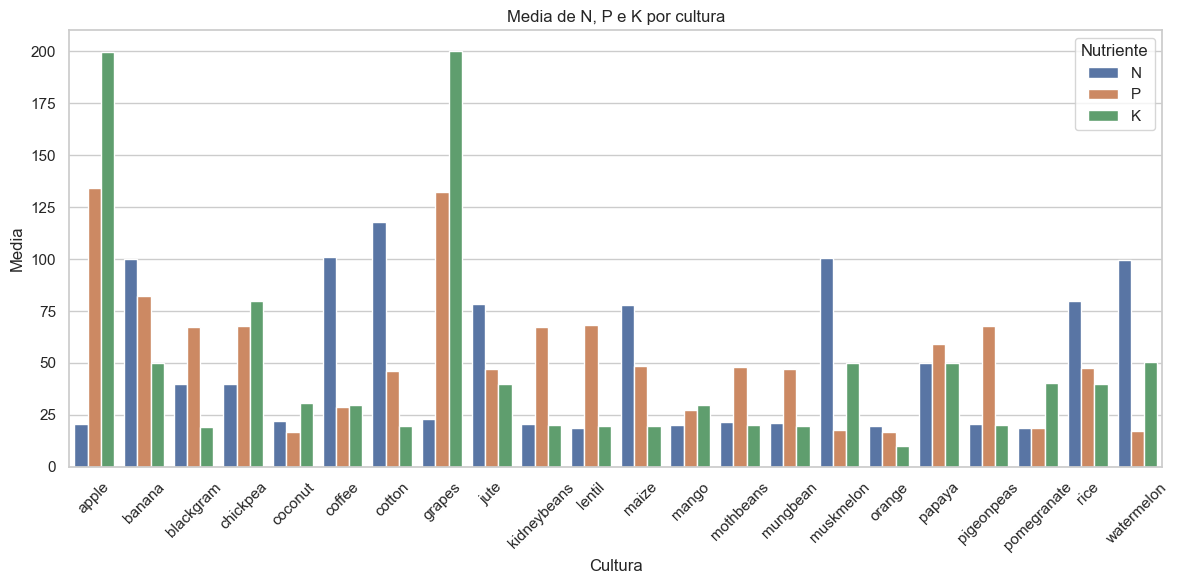

In [26]:
# Grafico 6 (opcional) - Nutrientes N, P e K por cultura (media)
npk_media = df.groupby("label")[["N", "P", "K"]].mean().reset_index()
npk_melt = npk_media.melt(id_vars="label", var_name="Nutriente", value_name="Media")

plt.figure(figsize=(12, 6))
sns.barplot(data=npk_melt, x="label", y="Media", hue="Nutriente")
plt.title("Media de N, P e K por cultura")
plt.xlabel("Cultura")
plt.ylabel("Media")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Principais achados da analise exploratoria
Os graficos indicam como as culturas se distribuem e quais variaveis apresentam maior dispersao. Em geral, observa-se variacao relevante em `rainfall`, `humidity` e `temperature` entre culturas, o que sugere que fatores climaticos sao determinantes na recomendacao.

O mapa de correlacao ajuda a identificar relacoes entre nutrientes e clima, enquanto os boxplots mostram culturas com faixas climaticas mais especificas ou mais amplas. Esses padroes orientam a interpretacao do perfil ideal de solo e clima para cada cultura.

## 5. Perfil ideal de solo e clima
Neste contexto, o **perfil ideal** e definido como a media das condicoes em que cada cultura aparece na base. Essa media nao representa uma verdade absoluta, mas sim uma referencia estatistica baseada nos dados observados.

In [28]:
perfil_culturas = df.groupby("label")[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].mean()
perfil_culturas.sort_values("rainfall", ascending=False).head()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,79.89,47.58,39.87,23.689332,82.272822,6.425471,236.181114
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
pigeonpeas,20.73,67.73,20.29,27.741762,48.061633,5.794175,149.457564


In [29]:
perfil_culturas.sort_values("temperature", ascending=False).head()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
papaya,49.88,59.05,50.04,33.723859,92.403388,6.741442,142.627839
mango,20.07,27.18,29.92,31.208770,50.156573,5.766373,94.704515
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
muskmelon,100.32,17.72,50.08,28.663066,92.342802,6.358805,24.689952
mungbean,20.99,47.28,19.87,28.525775,85.499975,6.723957,48.403601


In [30]:
perfil_culturas.sort_values("humidity", ascending=False).head()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
papaya,49.88,59.05,50.04,33.723859,92.403388,6.741442,142.627839
muskmelon,100.32,17.72,50.08,28.663066,92.342802,6.358805,24.689952
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
orange,19.58,16.55,10.01,22.765725,92.170209,7.016957,110.474969


## 6. Comparacao entre tres culturas
A selecao abaixo busca culturas com perfis distintos (por exemplo, maior chuva, maior temperatura e maior teor de algum nutriente). Caso culturas conhecidas estejam presentes, elas serao priorizadas automaticamente.

In [31]:
# Seleciona tres culturas automaticamente
preferidas = ["rice", "banana", "mango", "coffee", "cotton"]
disponiveis = perfil_culturas.index.tolist()

culturas_escolhidas = [c for c in preferidas if c in disponiveis][:3]

if len(culturas_escolhidas) < 3:
    # Escolhe culturas com perfis extremos
    max_rain = perfil_culturas["rainfall"].idxmax()
    max_temp = perfil_culturas["temperature"].idxmax()
    max_n = perfil_culturas["N"].idxmax()
    candidatos = [max_rain, max_temp, max_n]
    for c in candidatos:
        if c not in culturas_escolhidas:
            culturas_escolhidas.append(c)
    culturas_escolhidas = culturas_escolhidas[:3]

comparacao = perfil_culturas.loc[culturas_escolhidas]
comparacao

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,79.89,47.58,39.87,23.689332,82.272822,6.425471,236.181114
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
mango,20.07,27.18,29.92,31.208770,50.156573,5.766373,94.704515


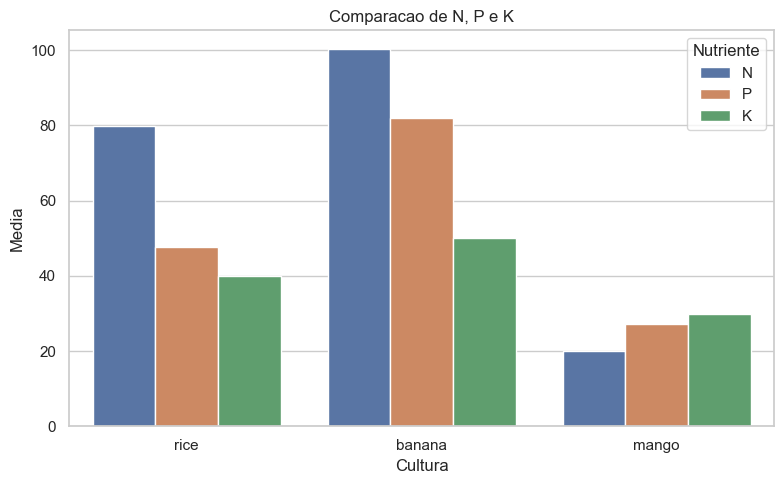

In [32]:
# Barras para N, P e K
comparacao_npk = comparacao[["N", "P", "K"]].reset_index().melt(
    id_vars="label", var_name="Nutriente", value_name="Media"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparacao_npk, x="label", y="Media", hue="Nutriente")
plt.title("Comparacao de N, P e K")
plt.xlabel("Cultura")
plt.ylabel("Media")
plt.tight_layout()
plt.show()

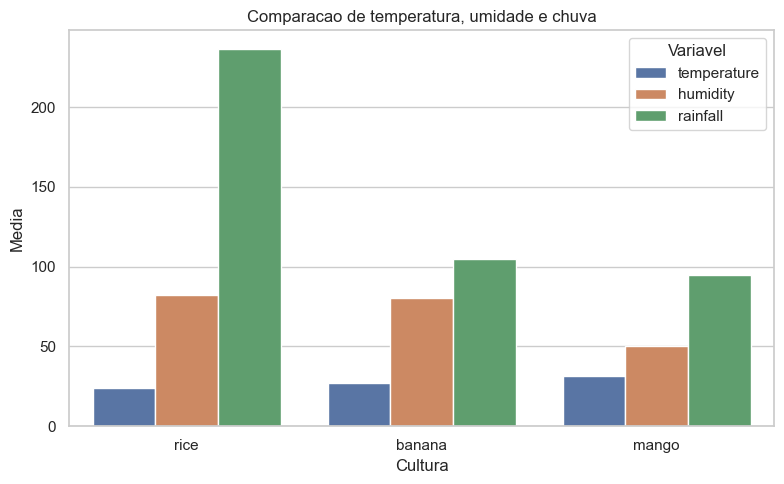

In [33]:
# Barras para temperatura, umidade e chuva
comparacao_clima = comparacao[["temperature", "humidity", "rainfall"]].reset_index().melt(
    id_vars="label", var_name="Variavel", value_name="Media"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparacao_clima, x="label", y="Media", hue="Variavel")
plt.title("Comparacao de temperatura, umidade e chuva")
plt.xlabel("Cultura")
plt.ylabel("Media")
plt.tight_layout()
plt.show()

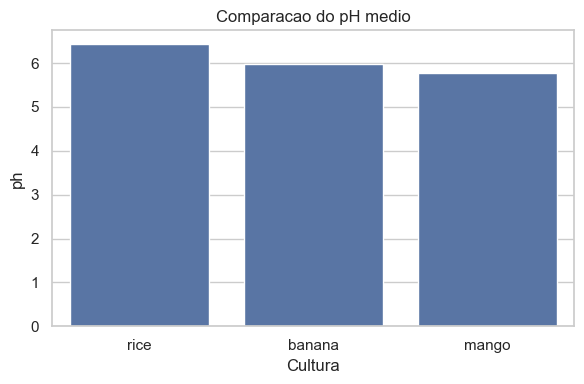

In [35]:
# Comparacao do pH
plt.figure(figsize=(6, 4))
sns.barplot(data=comparacao.reset_index(), x="label", y="ph")
plt.title("Comparacao do pH medio")
plt.xlabel("Cultura")
plt.ylabel("ph")
plt.tight_layout()
plt.show()

Com base na comparacao, e possivel identificar qual cultura apresenta maior umidade, maior precipitacao e maior temperatura media. Tambem se observa a diferenca nos nutrientes, indicando culturas que demandam mais N, P ou K.

A leitura conjunta desses graficos mostra como cada cultura se afasta ou se aproxima do perfil medio geral, o que e essencial para uma recomendacao mais precisa.

## 7. Preparacao dos dados para Machine Learning
A divisao entre treino e teste permite avaliar a capacidade de generalizacao dos modelos. O uso de `stratify=y` preserva a distribuicao das classes na amostra de teste.

Como o problema e multiclasse, utilizaremos acuracia, precisao macro, recall macro e F1-score macro.

In [37]:
X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 8. Modelagem preditiva
Serao treinados cinco modelos: Regressao Logistica, KNN, Arvore de Decisao, Random Forest e SVM. Modelos sensiveis a escala utilizam `StandardScaler` em pipeline.

In [38]:
modelos = {
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "Arvore de Decisao": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ])
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_pred),
        "Precisao Macro": precision_score(y_test, y_pred, average="macro"),
        "Recall Macro": recall_score(y_test, y_pred, average="macro"),
        "F1-Score Macro": f1_score(y_test, y_pred, average="macro")
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-Score Macro", ascending=False)
resultados_df

,Modelo,Acuracia,Precisao Macro,Recall Macro,F1-Score Macro
3,Random Forest,0.995455,0.995671,0.995455,0.995452
4,SVM,0.984091,0.985610,0.984091,0.984038
2,Arvore de Decisao,0.979545,0.980598,0.979545,0.979423
1,KNN,0.979545,0.980356,0.979545,0.979283
0,Regressao Logistica,0.972727,0.974022,0.972727,0.972464


## 9. Comparacao visual dos modelos
A seguir, comparamos o desempenho dos modelos por acuracia e F1-score macro. O F1-score macro e relevante em classificacao multiclasse porque equilibra precisao e recall para todas as classes de forma igualitaria.

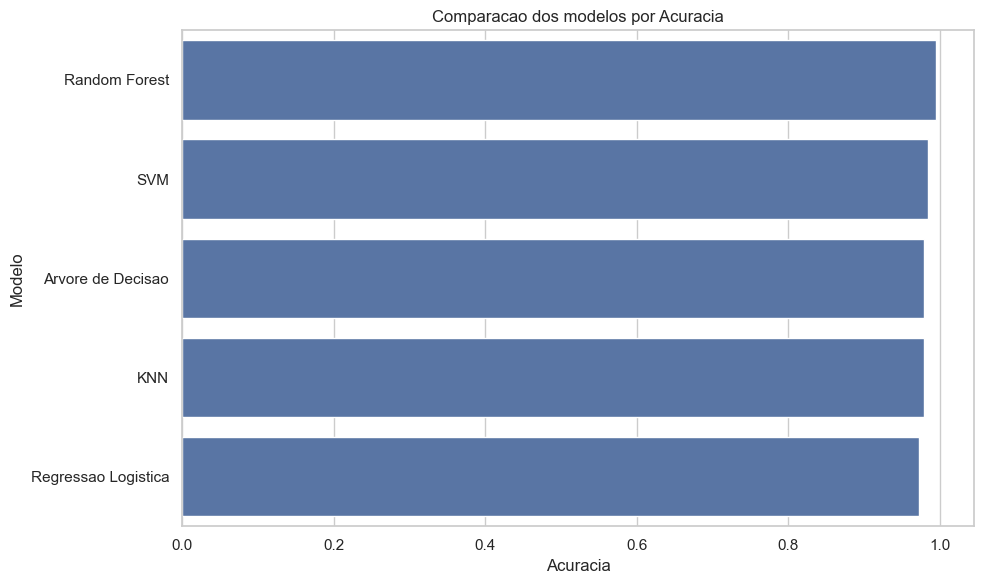

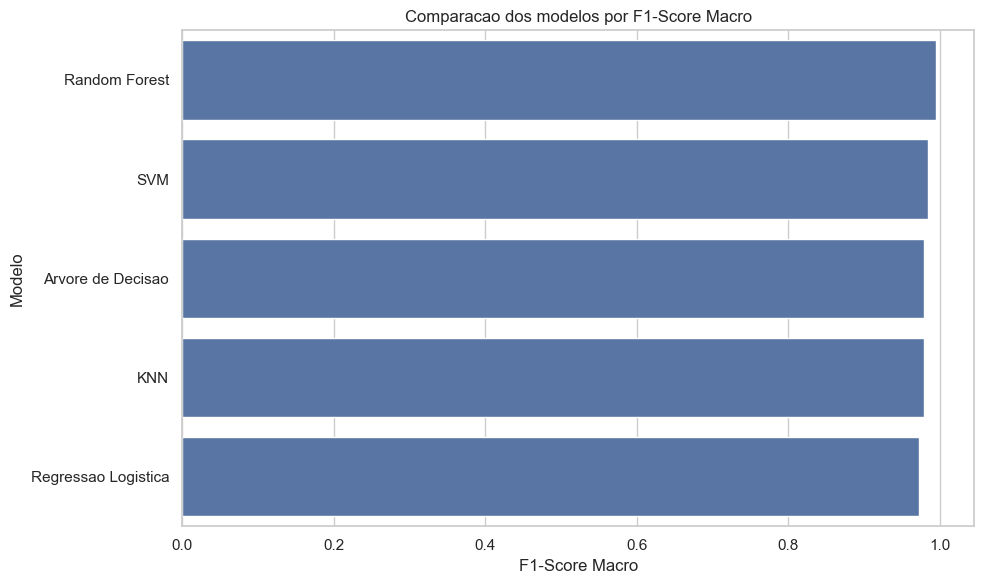

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=resultados_df, x="Acuracia", y="Modelo")
plt.title("Comparacao dos modelos por Acuracia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=resultados_df, x="F1-Score Macro", y="Modelo")
plt.title("Comparacao dos modelos por F1-Score Macro")
plt.tight_layout()
plt.show()

Os graficos evidenciam o modelo com melhor desempenho e o menos eficiente. O F1-score macro permite avaliar o equilibrio entre classes, o que e essencial quando se deseja uma recomendacao confiavel para varias culturas.

## 10. Relatorio do melhor modelo
Nesta etapa, selecionamos automaticamente o modelo com maior F1-score macro para gerar um relatorio detalhado e a matriz de confusao.

In [40]:
melhor_modelo_nome = resultados_df.iloc[0]["Modelo"]
melhor_modelo = modelos[melhor_modelo_nome]

y_pred_melhor = melhor_modelo.predict(X_test)
print("Melhor modelo:", melhor_modelo_nome)
print(classification_report(y_test, y_pred_melhor))

Melhor modelo: Random Forest
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        2

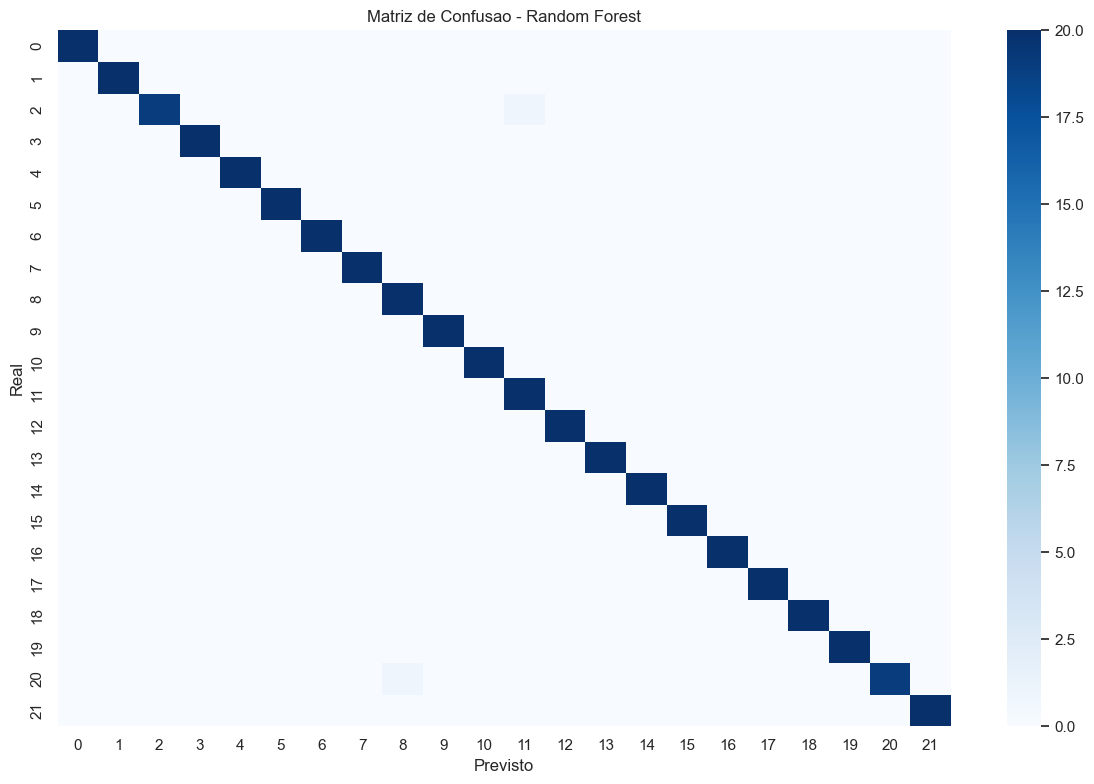

In [41]:
cm = confusion_matrix(y_test, y_pred_melhor)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title(f"Matriz de Confusao - {melhor_modelo_nome}")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

A matriz de confusao mostra onde o modelo acerta e onde confunde culturas similares. Se houver concentracao de erros entre certas culturas, isso indica que seus perfis sao proximos e exigem mais variaveis explicativas para separacao.

## 11. Validacao cruzada
A validacao cruzada oferece uma estimativa mais robusta do desempenho, pois avalia o modelo em diferentes particoes da base. Isso reduz o risco de conclusoes baseadas em uma unica divisao treino/teste.

In [42]:
scores = cross_val_score(melhor_modelo, X, y, cv=5, scoring="f1_macro")
print("Scores:", scores)
print("Media:", scores.mean())
print("Desvio padrao:", scores.std())

Scores: [0.99772585 0.99317755 0.99772585 0.99544315 0.98859495]
Media: 0.9945334723971616
Desvio padrao: 0.0034151025945517084


Se o desvio padrao for baixo, o desempenho tende a ser estavel entre as particoes. Um desvio alto indica maior variabilidade e possivel sensibilidade do modelo a amostras especificas.

## 12. Teste com dados simulados
A funcao abaixo simula o uso real do modelo para recomendar uma cultura a partir de valores de entrada.

In [44]:
def recomendar_cultura(N, P, K, temperature, humidity, ph, rainfall):
    entrada = pd.DataFrame([{
        "N": N,
        "P": P,
        "K": K,
        "temperature": temperature,
        "humidity": humidity,
        "ph": ph,
        "rainfall": rainfall
    }])
    predicao = melhor_modelo.predict(entrada)[0]
    return predicao

recomendar_cultura(
    N=90,
    P=40,
    K=40,
    temperature=25,
    humidity=80,
    ph=6.5,
    rainfall=200
)

'rice'

## 13. Conclusao
A analise evidenciou diferencas claras entre culturas quando se observa clima e nutrientes. O perfil ideal foi definido pela media das condicoes por cultura, funcionando como referencia estatistica para comparacoes.

A comparacao de tres culturas destacou contrastes em temperatura, umidade, chuva e nutrientes, reforcando que a recomendacao depende de multiplos fatores simultaneos.

O melhor modelo foi selecionado com base no F1-score macro, que equilibra desempenho entre classes. As metricas obtidas indicam bom potencial preditivo, especialmente se o F1-score macro e a acuracia estiverem elevados.

**Pontos fortes:**
- Analise exploratoria completa com graficos e interpretacao;
- Comparacao de multiplos modelos;
- Validacao cruzada para maior confiabilidade.

**Limitacoes:**
- A base pode nao representar todos os cenarios agricolas reais;
- Fatores como pragas, altitude, tipo de solo detalhado e epoca do ano nao foram considerados;
- O modelo depende da qualidade dos dados;
- A recomendacao e estatistica e nao substitui avaliacao agronomica profissional.

**Possiveis melhorias:**
- Incluir variaveis adicionais (tipo de solo, altitude, epoca do plantio);
- Avaliar modelos mais robustos ou com ajuste de hiperparametros;
- Coletar mais dados para aumentar a representatividade da base.